This notebook computes the Q-Variance equation from any OHLCV CSV file of price data, for horizons T = 1 to 26 weeks, and produces the red parabola:

σ² = σ₀² + (z − zoff)² / 2

Works whether Date is a column or the index — just drop in the path to your CSV file. Note that this code is for a single asset only, best results are obtained by averaging over a number of assets. Also, here we have used the example of the S&P 500 index, which represents an average over stock prices rather than a stock price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('default')

In [2]:
# CHANGE THIS TO YOUR FILE
CSV_FILE = "indexSP1928.csv"   # or "SPY.csv", "BTC-USD.csv", etc.

def load_prices(filepath):
    df = pd.read_csv(filepath)
    
    # Case 1: Date is a column
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date')
    
    # Case 2: First column is empty and index is date
    elif df.columns[0] == '' or 'Unnamed: 0' in df.columns[0]:
        df = df.rename(columns={df.columns[0]: 'Date'})
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date')
    
    # Prefer Adj Close → Close → last column
    price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close' if 'Close' in df.columns else df.columns[-1]
    prices = df[price_col].dropna()
    prices = prices.sort_index()
    
    print(f"Loaded {len(prices):,} daily prices from {prices.index[0].date()} to {prices.index[-1].date()}")
    print(f"Using price column: '{price_col}'")
    return prices

prices = load_prices(CSV_FILE)
log_returns = np.log(prices / prices.shift(1)).dropna()

#N = int(1000)
#sigma = 0.3/np.sqrt(252)
#log_returns = np.random.normal(0, sigma, N)

Loaded 24,376 daily prices from 1927-12-30 to 2025-01-15
Using price column: 'Close'


## 2. Compute Variance vs Scaled Return z for T = 1–26 weeks

In [4]:
rows = []
scale = np.sqrt(252)

print("Computing Q-Variance curve for T = 1 to 26 weeks...")
HORIZONS = 5*(np.arange(26)+1)   # does 1 to 26 weeks, can also do [5, 10, 20, 40, 80, 160]
for T in HORIZONS:
    i = 0
    while i + T <= len(log_returns):
        window = log_returns[i:i+T]     # T points
        if len(window) < T * 0.8:
            break

        x = window.sum()   # total price change over the period
        sigma = np.std(window, ddof=0) * scale      # ddof=0 means divisor is N, not N-1
        varcur = sigma**2
        z_raw = x / np.sqrt(T / 252.0)

        # REJECT BAD WINDOWS
        if not (np.isfinite(sigma) and sigma > 0 and np.isfinite(z_raw)):
            i += T
            continue

        rows.append({          # append row of data for this period
            "T": T,
            "z_raw": float(z_raw),
            "var": float(varcur)
        })
        i += T

df = pd.DataFrame(rows)

# CLEAN BEFORE DE-MEANING 
df = df[np.isfinite(df['z_raw']) & np.isfinite(df['var']) & (df['var'] > 0)]

# NOW de-mean safely, this step groups by T, and subtracts the group mean 
df["z"] = df.groupby(["T"])["z_raw"].transform(lambda g: g - g.mean())

df = df.drop(columns="z_raw")
df = df.dropna().reset_index(drop=True)  # Final clean, can save as e.g. parquet file

print(f"Generated {len(df["z"]):,} data points")

Computing Q-Variance curve for T = 1 to 26 weeks...
Generated 18,780 data points


## 3. Fit the Q-Variance Parabola

In [5]:
def q_variance_model(z, sigma0, zoff):
    return sigma0**2 + (z - zoff)**2 / 2

# Binning
zmax = 0.6
Z_BINS = np.linspace(-zmax, zmax, 61)
bin_means, bin_edges, _ = binned_statistic(df["z"], df["var"], statistic='mean', bins=Z_BINS)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
valid = ~np.isnan(bin_means)

# Fit
popt, pcov = curve_fit(q_variance_model, bin_centers[valid], bin_means[valid],
                       p0=[0.25, 0.02], bounds=([0.01, -0.1], [0.5, 0.1]))
sigma0_fit, zoff_fit = popt
perr = np.sqrt(np.diag(pcov))

# R²
predicted = q_variance_model(bin_centers[valid], *popt)
ss_res = np.sum((bin_means[valid] - predicted)**2)
ss_tot = np.sum((bin_means[valid] - np.mean(bin_means[valid]))**2)
r_squared = 1 - ss_res / ss_tot

print(f"\nQ-Variance Fit Results:")
print(f"  σ₀   = {sigma0_fit:.4f} ± {perr[0]:.4f}")
print(f"  zoff = {zoff_fit:.4f} ± {perr[1]:.4f}")
print(f"  R²   = {r_squared:.4f}")


Q-Variance Fit Results:
  σ₀   = 0.1375 ± 0.0108
  zoff = 0.0149 ± 0.0085
  R²   = 0.8572


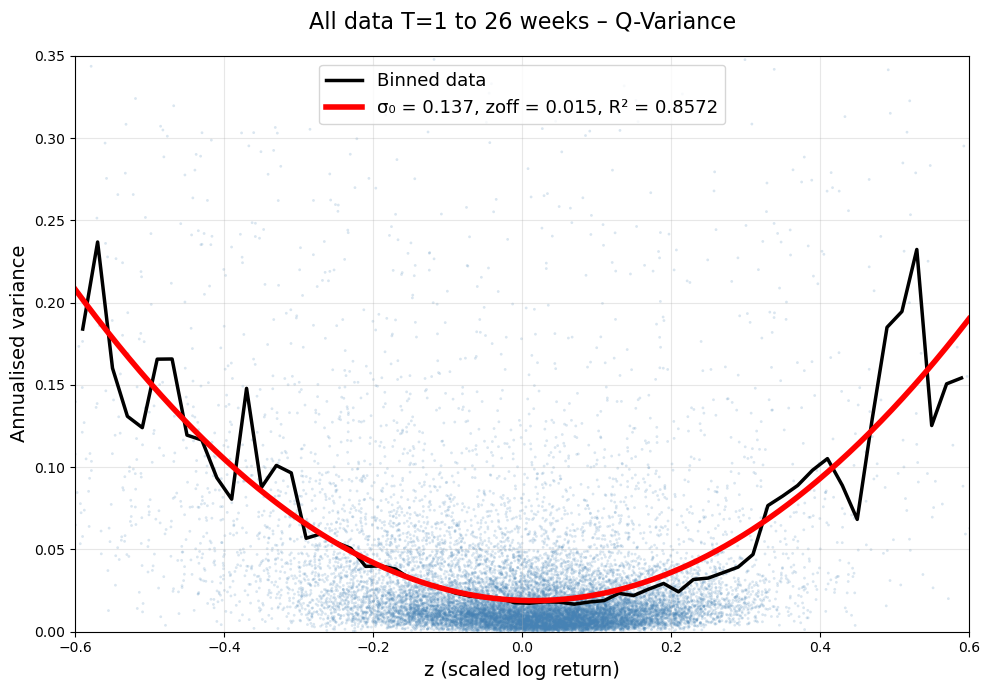

In [6]:
plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(df["z"], df["var"], c='steelblue', alpha=0.2, s=4, edgecolor='none')

# Binned data
plt.plot(bin_centers[valid], bin_means[valid], 'k-', lw=2.5, label='Binned data')

# Q-Variance fit
z_fine = np.linspace(-zmax, zmax, 500)
plt.plot(z_fine, q_variance_model(z_fine, *popt),
         color='red', lw=4,
         label=f'σ₀ = {sigma0_fit:.3f}, zoff = {zoff_fit:.3f}, R² = {r_squared:.4f}')

plt.xlabel('z (scaled log return)', fontsize=14)
plt.ylabel('Annualised variance', fontsize=14)
plt.title('All data T=1 to 26 weeks – Q-Variance', fontsize=16, pad=20)
plt.xlim(-0.6, 0.6)
plt.ylim(0, 0.35)
plt.grid(alpha=0.3)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()

# Save for publication
# plt.savefig("Q_Variance_Parabola.png", dpi=300, bbox_inches='tight')
# plt.savefig("Q_Variance_Parabola.pdf", bbox_inches='tight')
plt.show()

## Linear Regression

We next plot variance v versus z^2. In theory the linear coefficient should be 0.5, but this analysis misses the fact that variance should be averaged over each z, and the estimate is subject to noise. To improve results we filter points with |z| > 0.6. Note that q-variance is based on a first-order approximation to the underlying dynamics.

Slope: 0.5147
Intercept: 0.0165
$R^2$: 0.1639


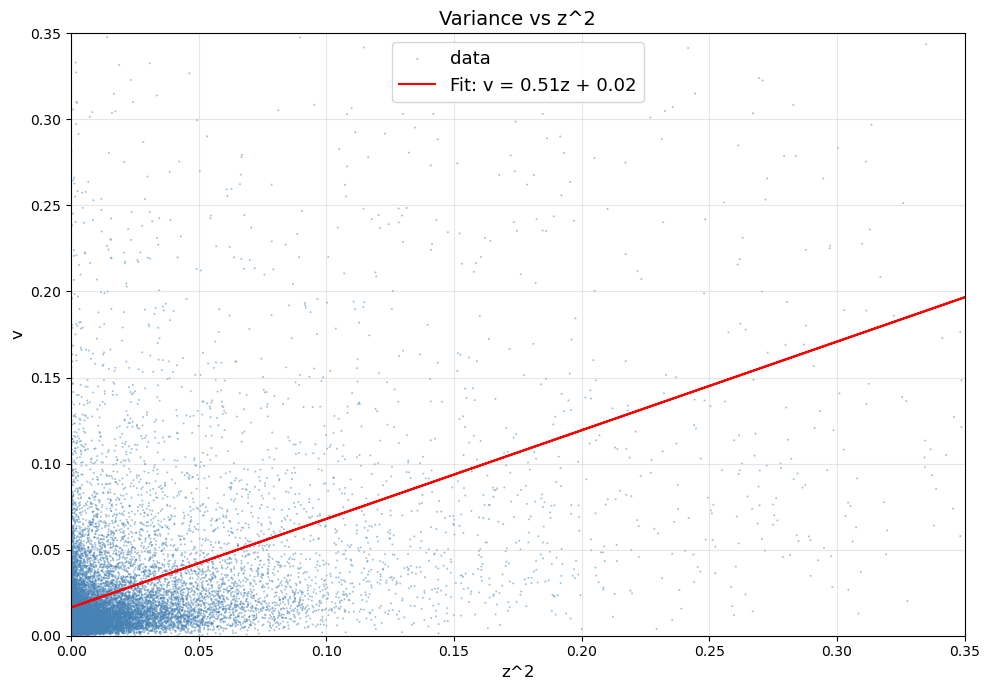

In [7]:
from scipy import stats

df = df[df['z'].abs() <= 0.6]  # filter extreme points, fit is first-order

df['z2'] = df['z']**2
slope, intercept, r_value, p_value, std_err = stats.linregress(df.z2, df["var"])

# Calculate the regression line values
line = slope * df.z2+ intercept
r_squared = r_value**2

# do confidence intervals
# 1. Regression basics
n = len(df.z2)
dof = n - 2
t_score = stats.t.ppf(0.975, dof) # 95% confidence
v_pred = intercept + slope * df.z2

# 2. Standard Error of the Estimate
residuals = df["var"] - v_pred
s_err = np.sqrt(np.sum(residuals**2) / dof) 

# 3. Calculate intervals
z_mean = np.mean(df.z2)
z_sq_diff = np.sum((df.z2 - z_mean)**2)

# SE for Confidence Interval (the fit)
se_ci = s_err * np.sqrt(1/n + (df.z2 - z_mean)**2 / z_sq_diff)

plt.figure(figsize=(10, 7))
# Scatter plot
plt.scatter(df.z2, df["var"], c='steelblue', alpha=0.5, s=2, edgecolor='none', label='data')
plt.plot(df.z2, line, color='red', label=f'Fit: v = {slope:.2f}z + {intercept:.2f}')
#plt.fill_between(df.z2, v_pred - t_score * se_ci, v_pred + t_score * se_ci,color='red', alpha=0.15, label='95% CI')

# Add a text box for slope, intercept, and R^2
stats_text = f'Slope: {slope:.4f}\nIntercept: {intercept:.4f}\n$R^2$: {r_squared:.4f}'
#plt.text(1, 2.5, stats_text, bbox=dict(facecolor='white', alpha=0.5))
print(stats_text)

plt.xlabel('z^2', fontsize=12)
plt.ylabel('v', fontsize=12)
plt.title('Variance vs z^2', fontsize=14)
plt.xlim(0, 0.35)
plt.ylim(0, 0.35)
plt.grid(alpha=0.3)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()

plt.show()